# DodoGo Google Maps to OSM Migration (NB05)

This notebook documents the infrastructure migration from a Google-heavy mapping stack to a hybrid OSM-based stack. The case is included because it links data engineering, GIS decisions and operating cost control.

| Metric | Before | After | Change |
|---|---|---|---|
| Mapping cost index | 100 | 14.5 | -85.5% |
| Geocoding source | Google geocoding | Custom OSM road-point index | Better local context |
| Routing | Google routing APIs | OSRM-style routing | Vendor cost removed |
| Remaining dependency | Five Google APIs | Places API only | Lower vendor exposure |

The key point is not only the reduction in cost. The custom OSM geocoder also fits Mauritius better because many local roads are unnamed or weakly represented in generic commercial geocoding.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

C = {'primary':'#1565C0','secondary':'#FF5722','success':'#4CAF50',
     'warning':'#FF9800','danger':'#E53935','purple':'#9C27B0',
     'google':'#4285F4','osm':'#7EBC6F','gray':'#9E9E9E'}
plt.rcParams.update({'figure.figsize':(14,8),'font.size':11,'figure.facecolor':'white',
    'axes.facecolor':'#FAFAFA','axes.grid':True,'grid.alpha':0.3,'figure.dpi':120})
print("Libraries loaded.")



Libraries loaded.


## 1. Relative Cost Analysis

The public version reports normalized cost indexes rather than exact vendor cost values. The baseline month is set to 100, and all later values are expressed relative to that baseline.


In [ ]:
# Relative mapping-cost index, baseline month = 100
cost_idx = pd.DataFrame({
    'month': ['Oct 2025','Nov 2025','Dec 2025','Jan 2026','Feb 2026','Mar 2026*'],
    'total_index': [100.0, 32.1, 37.3, 19.4, 14.5, 14.7],
    'places_index': [63.7, 17.2, 22.5, 19.4, 14.5, 14.7],
    'geocoding_index': [14.0, 14.9, 14.8, 0.0, 0.0, 0.0],
    'distance_matrix_index': [17.7, 0.0, 0.0, 0.0, 0.0, 0.0],
    'directions_index': [4.5, 0.0, 0.0, 0.0, 0.0, 0.0],
    'order_volume_index': [100.0, 151.5, 193.5, 165.4, 135.3, 57.5]
})
cost_idx['savings_index'] = cost_idx['total_index'].iloc[0] - cost_idx['total_index']
cost_idx['cost_per_order_index'] = cost_idx['total_index'] / cost_idx['order_volume_index'] * 100

print("=" * 70)
print("GOOGLE MAPS TO OSM MIGRATION - RELATIVE COST SUMMARY")
print("=" * 70)
print(f"{'Month':12s} {'Total idx':>10s} {'Places':>9s} {'Geocode':>9s} {'Matrix':>9s} {'Directions':>11s}")
print("-" * 70)
for _, r in cost_idx.iterrows():
    print(f"{r['month']:12s} {r['total_index']:>10.1f} {r['places_index']:>9.1f} "
          f"{r['geocoding_index']:>9.1f} {r['distance_matrix_index']:>9.1f} {r['directions_index']:>11.1f}")
print("-" * 70)
reduction = (1 - cost_idx['total_index'].iloc[-2] / cost_idx['total_index'].iloc[0]) * 100
print(f"Cost index reduction: 100.0 to {cost_idx['total_index'].iloc[-2]:.1f} = -{reduction:.1f}%")
print("Google APIs removed: 4 of 5")
print(f"Stable cost-per-order index: {cost_idx['cost_per_order_index'].iloc[-2]:.1f} vs 100.0 baseline")
print("\nCost-per-order index by month:")
for _, r in cost_idx.iterrows():
    print(f"  {r['month']:12s}: {r['cost_per_order_index']:.1f} (baseline=100)")


GOOGLE MAPS TO OSM MIGRATION - RELATIVE COST SUMMARY
Month         Total idx    Places   Geocode    Matrix  Directions
----------------------------------------------------------------------
Oct 2025          100.0      63.7      14.0      17.7         4.5
Nov 2025           32.1      17.2      14.9       0.0         0.0
Dec 2025           37.3      22.5      14.8       0.0         0.0
Jan 2026           19.4      19.4       0.0       0.0         0.0
Feb 2026           14.5      14.5       0.0       0.0         0.0
Mar 2026*          14.7      14.7       0.0       0.0         0.0
----------------------------------------------------------------------
Cost index reduction: 100.0 to 14.5 = -85.5%
Google APIs removed: 4 of 5
Stable cost-per-order index: 10.7 vs 100.0 baseline

Cost-per-order index by month:
  Oct 2025    : 100.0 (baseline=100)
  Nov 2025    : 21.2 (baseline=100)
  Dec 2025    : 19.3 (baseline=100)
  Jan 2026    : 11.7 (baseline=100)
  Feb 2026    : 10.7 (baseline=100)
  Mar

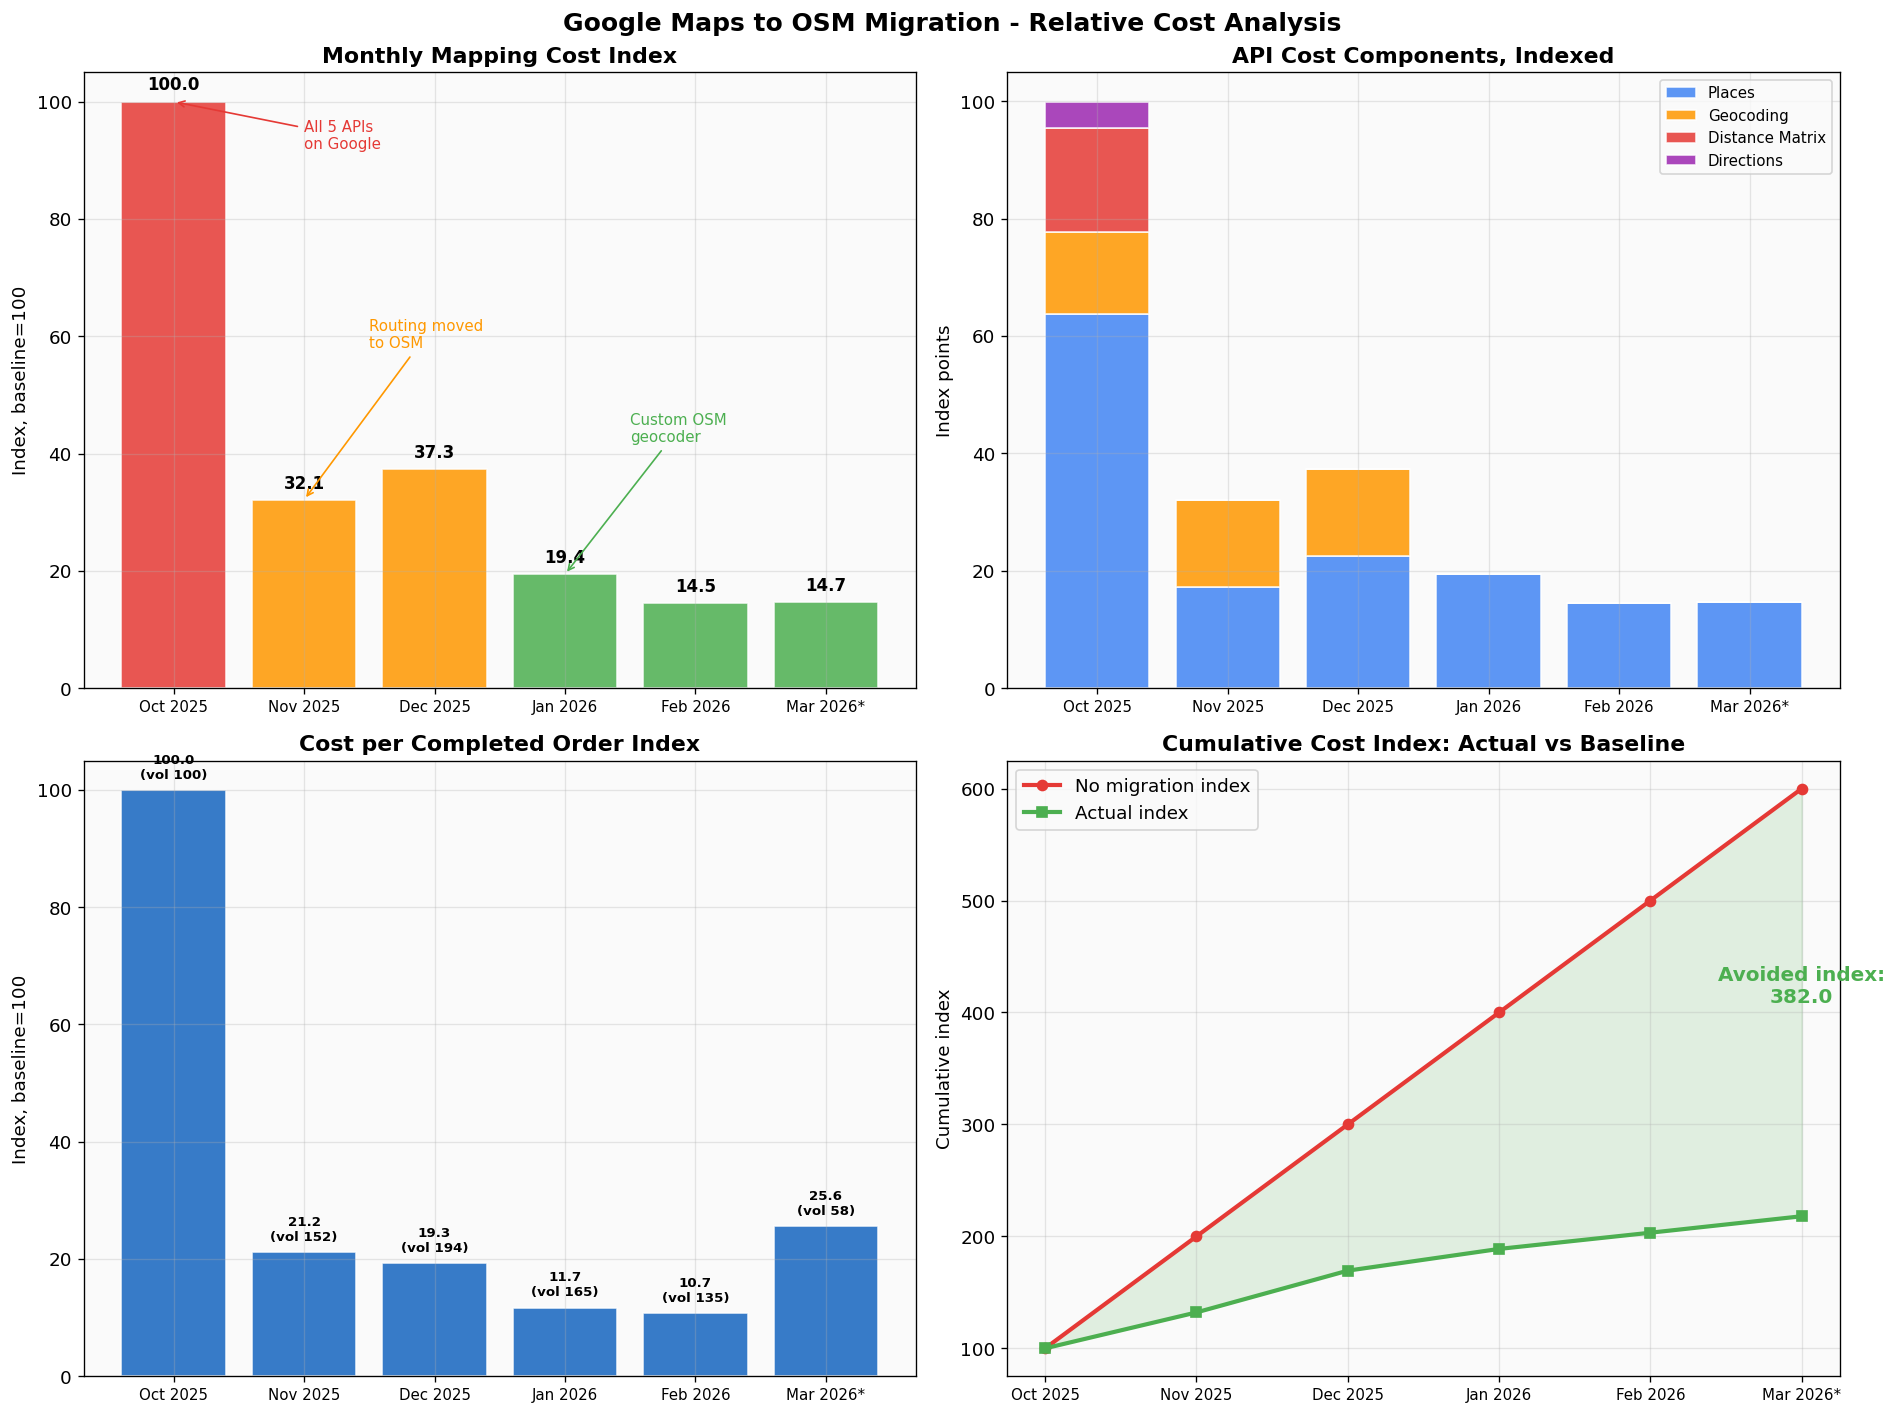


=== SAVINGS SUMMARY ===
Baseline monthly cost index:       100.0
Stable monthly cost index:         14.5
Six-month actual cumulative index: 218.1
Avoided cumulative index:          381.9


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Google Maps to OSM Migration - Relative Cost Analysis', fontsize=15, fontweight='bold')

# Monthly cost index
ax = axes[0,0]
x = range(len(cost_idx))
bars = ax.bar(x, cost_idx['total_index'], color=[C['danger']]+[C['warning']]*2+[C['success']]*3, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(cost_idx['month'], fontsize=9)
ax.set_title('Monthly Mapping Cost Index', fontweight='bold'); ax.set_ylabel('Index, baseline=100')
for b, v in zip(bars, cost_idx['total_index']):
    ax.text(b.get_x()+b.get_width()/2, v+2, f'{v:.1f}', ha='center', fontweight='bold', fontsize=10)
ax.annotate('All 5 APIs\non Google', xy=(0, 100), xytext=(1, 92),
            arrowprops=dict(arrowstyle='->', color=C['danger']), fontsize=9, color=C['danger'])
ax.annotate('Routing moved\nto OSM', xy=(1, 32.1), xytext=(1.5, 58),
            arrowprops=dict(arrowstyle='->', color=C['warning']), fontsize=9, color=C['warning'])
ax.annotate('Custom OSM\ngeocoder', xy=(3, 19.4), xytext=(3.5, 42),
            arrowprops=dict(arrowstyle='->', color=C['success']), fontsize=9, color=C['success'])

# API component index
ax = axes[0,1]
bottom = np.zeros(len(cost_idx))
for api, col_name, color in [('Places','places_index',C['google']),('Geocoding','geocoding_index',C['warning']),
                             ('Distance Matrix','distance_matrix_index',C['danger']),('Directions','directions_index',C['purple'])]:
    vals = cost_idx[col_name].values
    ax.bar(x, vals, bottom=bottom, label=api, color=color, alpha=0.85, edgecolor='white')
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(cost_idx['month'], fontsize=9)
ax.set_title('API Cost Components, Indexed', fontweight='bold'); ax.set_ylabel('Index points')
ax.legend(fontsize=9)

# Cost per order index
ax = axes[1,0]
ax.bar(x, cost_idx['cost_per_order_index'], color=C['primary'], alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(cost_idx['month'], fontsize=9)
ax.set_title('Cost per Completed Order Index', fontweight='bold'); ax.set_ylabel('Index, baseline=100')
for b, v, o in zip(ax.patches, cost_idx['cost_per_order_index'], cost_idx['order_volume_index']):
    ax.text(b.get_x()+b.get_width()/2, v+2, f'{v:.1f}\n(vol {o:.0f})',
            ha='center', fontsize=8, fontweight='bold')

# Cumulative index comparison
ax = axes[1,1]
hypothetical = cost_idx['total_index'].iloc[0] * np.arange(1, len(cost_idx)+1)
actual_cum = cost_idx['total_index'].cumsum()
savings_cum = hypothetical - actual_cum.values
ax.plot(x, hypothetical, color=C['danger'], lw=2.5, marker='o', label='No migration index')
ax.plot(x, actual_cum, color=C['success'], lw=2.5, marker='s', label='Actual index')
ax.fill_between(x, actual_cum, hypothetical, alpha=0.15, color=C['success'])
ax.set_xticks(x); ax.set_xticklabels(cost_idx['month'], fontsize=9)
ax.set_title('Cumulative Cost Index: Actual vs Baseline', fontweight='bold')
ax.set_ylabel('Cumulative index'); ax.legend()
ax.annotate(f'Avoided index:\n{savings_cum[-1]:.1f}', xy=(5, (hypothetical[-1]+actual_cum.values[-1])/2),
            fontsize=12, fontweight='bold', color=C['success'], ha='center')

plt.tight_layout(); plt.show()

print("\n=== SAVINGS SUMMARY ===")
print("Baseline monthly cost index:       100.0")
print(f"Stable monthly cost index:         {cost_idx['total_index'].iloc[-2]:.1f}")
print(f"Six-month actual cumulative index: {actual_cum.values[-1]:.1f}")
print(f"Avoided cumulative index:          {savings_cum[-1]:.1f}")


### Cost Analysis Interpretation

The migration reduced the mapping cost index from 100 to 14.5, an 85.5% reduction. This was achieved gradually rather than through a single replacement.

First, routing and distance calculations moved away from Google services. This produced the largest early drop because those calls were frequent and technically easier to replace on a small island. Then the custom OSM reverse geocoder removed the need for paid geocoding calls. After that, only Places API remained for autocomplete and point-of-interest search.

The per-order cost index fell by almost an order of magnitude by the stable post-migration phase. This matters because platform growth should not make infrastructure cost grow at the same rate as order volume.


## 2. Custom OSM Geocoder

### 2.1 Why a Local Geocoder Was Needed

Mauritius has many roads and pickup points where commercial geocoding returns weak labels such as unnamed road. For ride-hailing, this is not only a data-quality issue. Poor pickup descriptions create confusion between passengers and drivers.

### 2.2 Architecture

1. Source: Mauritius OSM extract from Geofabrik.
2. Road extraction: keep highway features with identifiers, names, types and geometry.
3. Densification: reproject to a local metric CRS and interpolate points along roads.
4. Administrative context: join road points with district, city, area and village polygons.
5. Address formatting: use road names where available and fall back to area and village context where they are missing.
6. Query layer: use KD-Tree nearest-neighbor search for fast reverse geocoding.

### 2.3 Main Design Decisions

| Decision | Reason |
|---|---|
| Full OSM extract | Offline, repeatable and not rate-limited |
| Local metric CRS | Road-point spacing must be measured in meters |
| Dense road points | Better pickup context than sparse road centroids |
| KD-Tree | Simple and fast nearest-neighbor lookup |
| Administrative spatial join | Adds district and village context to weak road names |
| Road-name fallback | Prevents generic unnamed-road outputs |

The resulting system is not a full address database with building numbers, but it is a strong fit for reverse geocoding pickup points on an island road network.


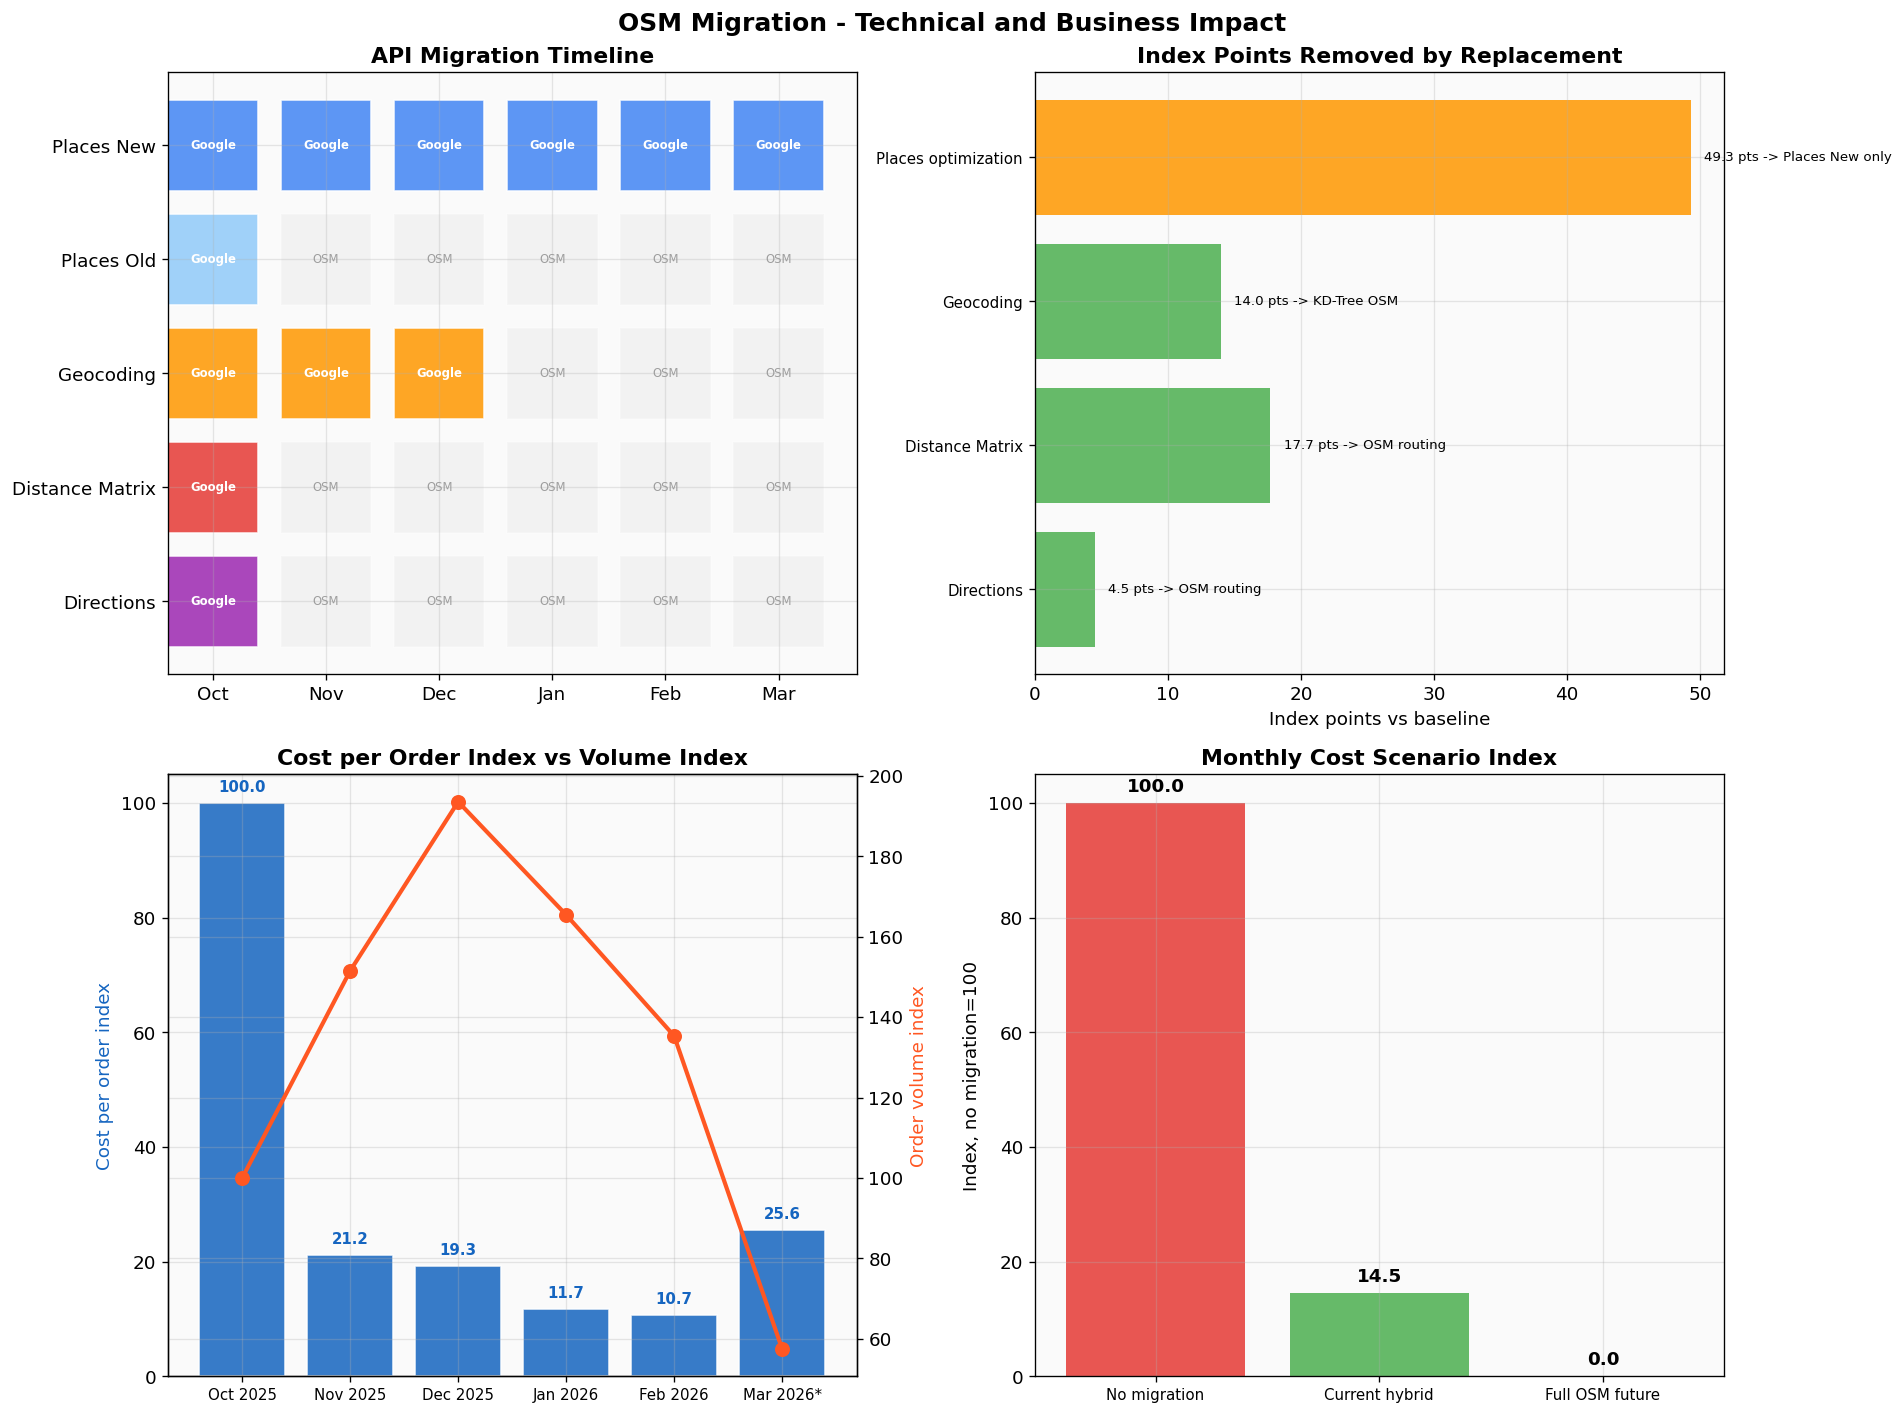


=== KEY METRICS ===
Peak cost index:                 100.0
Current cost index:              14.5
Reduction:                       85.5%
Cost-per-order index:            100.0 to 10.7
Google APIs removed:             4 of 5


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('OSM Migration - Technical and Business Impact', fontsize=15, fontweight='bold')

# API migration timeline
ax = axes[0,0]
apis = ['Directions', 'Distance Matrix', 'Geocoding', 'Places (Old)', 'Places (New)']
timeline = {
    'Directions':      [1, 0, 0, 0, 0, 0],
    'Distance Matrix': [1, 0, 0, 0, 0, 0],
    'Geocoding':       [1, 1, 1, 0, 0, 0],
    'Places (Old)':    [1, 0, 0, 0, 0, 0],
    'Places (New)':    [1, 1, 1, 1, 1, 1],
}
months_lbl = ['Oct','Nov','Dec','Jan','Feb','Mar']
colors_api = [C['purple'], C['danger'], C['warning'], '#90CAF9', C['google']]
for i_api, (api, active) in enumerate(timeline.items()):
    for j, a in enumerate(active):
        color = colors_api[i_api] if a else '#E0E0E0'
        ax.barh(i_api, 0.8, left=j, color=color, alpha=0.85 if a else 0.3, edgecolor='white')
        ax.text(j+0.4, i_api, 'Google' if a else 'OSM', ha='center', va='center', fontsize=7,
                fontweight='bold' if a else 'normal', color='white' if a else C['gray'])
ax.set_yticks(range(len(apis))); ax.set_yticklabels(apis)
ax.set_xticks([x+0.4 for x in range(6)]); ax.set_xticklabels(months_lbl)
ax.set_title('API Migration Timeline', fontweight='bold')

# Replacement contribution
ax = axes[0,1]
labels_rep = ['Directions', 'Distance Matrix', 'Geocoding', 'Places optimization']
savings_rep = [4.5, 17.7, 14.0, 49.3]
replacements_names = ['OSM routing', 'OSM routing', 'KD-Tree OSM', 'Places New only']
ax.barh(range(4), savings_rep, color=[C['success']]*3+[C['warning']], alpha=0.85)
ax.set_yticks(range(4)); ax.set_yticklabels(labels_rep, fontsize=9)
ax.set_title('Index Points Removed by Replacement', fontweight='bold'); ax.set_xlabel('Index points vs baseline')
for i_r, (s, rn) in enumerate(zip(savings_rep, replacements_names)):
    ax.text(s+1, i_r, f'{s:.1f} pts -> {rn}', va='center', fontsize=8)

# Cost per order vs volume
ax = axes[1,0]
ax2 = ax.twinx()
ax.bar(range(len(cost_idx)), cost_idx['cost_per_order_index'], color=C['primary'], alpha=0.85, edgecolor='white')
ax2.plot(range(len(cost_idx)), cost_idx['order_volume_index'], color=C['secondary'], lw=2.5, marker='o', ms=8)
ax.set_xticks(range(len(cost_idx))); ax.set_xticklabels(cost_idx['month'], fontsize=9)
ax.set_title('Cost per Order Index vs Volume Index', fontweight='bold')
ax.set_ylabel('Cost per order index', color=C['primary'])
ax2.set_ylabel('Order volume index', color=C['secondary'])
for i_b, c in enumerate(cost_idx['cost_per_order_index']):
    ax.text(i_b, c+2, f'{c:.1f}', ha='center', fontsize=9, fontweight='bold', color=C['primary'])

# Scenario projection index
ax = axes[1,1]
scenario_names = ['No migration', 'Current hybrid', 'Full OSM future']
scenario_vals = [100.0, 14.5, 0.0]
colors_s = [C['danger'], C['success'], C['osm']]
bars = ax.bar(range(3), scenario_vals, color=colors_s, alpha=0.85)
ax.set_xticks(range(3)); ax.set_xticklabels(scenario_names, fontsize=9)
ax.set_title('Monthly Cost Scenario Index', fontweight='bold'); ax.set_ylabel('Index, no migration=100')
for b, v in zip(bars, scenario_vals):
    ax.text(b.get_x()+b.get_width()/2, v+2, f'{v:.1f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout(); plt.show()

print("\n=== KEY METRICS ===")
print("Peak cost index:                 100.0")
print(f"Current cost index:              {cost_idx['total_index'].iloc[-2]:.1f}")
print(f"Reduction:                       {(1-cost_idx['total_index'].iloc[-2]/cost_idx['total_index'].iloc[0])*100:.1f}%")
print(f"Cost-per-order index:            100.0 to {cost_idx['cost_per_order_index'].iloc[-2]:.1f}")
print("Google APIs removed:             4 of 5")


### Migration Impact

1. Mapping cost index fell by 85.5% from the baseline month to the stable post-migration month.
2. Vendor exposure fell from five Google APIs to one remaining Google dependency.
3. Per-order mapping cost became much less sensitive to order growth.
4. Geocoding quality improved for local pickup descriptions because the OSM fallback includes area and district context.

The remaining dependency is Places API for autocomplete and business/POI search. This is harder to replace because it requires fuzzy matching and up-to-date business names. A future local POI layer from OSM, tourism data and business registry sources could reduce this dependency further.


## 3. Pipeline Steps

1. Download the Mauritius OSM extract.
2. Extract road network features.
3. Reproject to a local metric CRS.
4. Densify roads into regularly spaced points.
5. Reproject back to latitude and longitude.
6. Spatially join points to administrative boundaries.
7. Inherit road names from parent road segments.
8. Format fallback addresses for missing road names.
9. Build a KD-Tree index for nearest-neighbor lookup.
10. Query user coordinates and return the nearest contextual address.

**Stack:** Python, GeoPandas, Shapely, PyProj, spatial joins and sklearn KDTree.

**Limitations:**
1. The system does not provide building or house numbers.
2. Accuracy depends on road-point spacing.
3. Some boundary edge cases need manual review.
4. A formal benchmark against Google was not included in the this version.
5. Business POI names still require a separate autocomplete layer.


## 4. Notebook Summary

| Aspect | Detail |
|---|---|
| Problem | Mapping vendor cost and weak local geocoding quality |
| Solution | Hybrid OSM migration for routing, distance and reverse geocoding |
| Custom build | Road-point database with KD-Tree reverse geocoding |
| Cost impact | Mapping cost index fell by 85.5% |
| Quality impact | Better pickup context for unnamed or weakly labelled roads |
| Scalability | Cost no longer grows linearly with order volume |
| Remaining dependency | Places API for autocomplete and POI search |

NB05 supports the thesis recommendation that platform analytics should include infrastructure decisions, not only customer and driver models. For a small island market, local geospatial engineering can reduce vendor dependency while improving service quality.
